In [1]:
# IMPORT LIBRARY
import os
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import kagglehub

In [2]:
# DOWNLOAD DATASET
DATA_PATH = kagglehub.dataset_download("colorlabeilat/seathru-dataset")
print("Dataset downloaded to:", DATA_PATH)
print("Scenes:", os.listdir(DATA_PATH))

100%|██████████| 30.2G/30.2G [05:12<00:00, 104MB/s] 

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/colorlabeilat/seathru-dataset/versions/3
Scenes: ['D1', 'D3', 'D4', 'D5', 'D2']


In [3]:
# CONFIG
SCENES = ["D1", "D2", "D3", "D4", "D5"]

PATCH_SIZE = 256
BATCH_SIZE = 16
SEED = 42

In [4]:
# BUILD IMAGE-DEPTH PAIRS
all_pairs = []

for scene in SCENES:
    base_path = os.path.join(DATA_PATH, scene, scene)

    img_dir = os.path.join(base_path, "linearPNG")

    # D4 special case
    if os.path.exists(os.path.join(base_path, "depth")):
        depth_dir = os.path.join(base_path, "depth")
    elif os.path.exists(os.path.join(base_path, "depth_resized")):
        depth_dir = os.path.join(base_path, "depth_resized")
    else:
        print(f"Skipping {scene}: no depth folder")
        continue

    img_files = sorted(os.listdir(img_dir))
    depth_files = sorted(os.listdir(depth_dir))

    img_dict = {
        os.path.splitext(f)[0]: f
        for f in img_files
    }

    depth_dict = {
        os.path.splitext(f)[0].replace("depth", ""): f
        for f in depth_files
    }

    common_keys = sorted(
        set(img_dict.keys()) & set(depth_dict.keys())
    )

    print(f"{scene}: {len(common_keys)} matched pairs")

    for key in common_keys:
        all_pairs.append(
            (
                os.path.join(img_dir, img_dict[key]),
                os.path.join(depth_dir, depth_dict[key])
            )
        )

print("\nTotal image-depth pairs:", len(all_pairs))

D1: 622 matched pairs
D2: 319 matched pairs
D3: 68 matched pairs
D4: 153 matched pairs
D5: 43 matched pairs

Total image-depth pairs: 1205


In [5]:
# COMPUTE GLOBAL DEPTH MAX
depth_max_values = []

for _, depth_path in all_pairs:
    depth = cv2.imread(depth_path, cv2.IMREAD_UNCHANGED).astype(np.float32)
    depth_max_values.append(np.max(depth))

GLOBAL_DEPTH_MAX = np.max(depth_max_values)
print("GLOBAL_DEPTH_MAX:", GLOBAL_DEPTH_MAX)

np.save("global_depth_max.npy", GLOBAL_DEPTH_MAX)

GLOBAL_DEPTH_MAX: 26.075403


In [6]:
# SPLIT BEFORE PATCHING
train_pairs, test_pairs = train_test_split(
    all_pairs,
    test_size=0.15,
    random_state=SEED
)

train_pairs, val_pairs = train_test_split(
    train_pairs,
    test_size=0.15,
    random_state=SEED
)

print(f"Train images: {len(train_pairs)}")
print(f"Val images: {len(val_pairs)}")
print(f"Test images: {len(test_pairs)}")


# save splits
np.save("train_pairs.npy", train_pairs)
np.save("val_pairs.npy", val_pairs)
np.save("test_pairs.npy", test_pairs)

Train images: 870
Val images: 154
Test images: 181


In [7]:
# SAVE CONFIG
config = {
    "PATCH_SIZE": PATCH_SIZE,
    "BATCH_SIZE": BATCH_SIZE,
    "GLOBAL_DEPTH_MAX": float(GLOBAL_DEPTH_MAX),
    "SEED": SEED
}

np.save("preprocessing_config.npy", config)

In [8]:
# LOADER RGB + DEPTH + MASK
def load_image_depth(img_file, depth_file):
    img = cv2.imread(img_file, cv2.IMREAD_UNCHANGED)

    if img is None:
        return None

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32)

    # auto detect 8-bit or 16-bit
    if img.max() > 255:
        img = img / 65535.0
    else:
        img = img / 255.0

    # normalize RGB to [-1, 1]
    img = img * 2.0 - 1.0

    depth = cv2.imread(depth_file, cv2.IMREAD_UNCHANGED).astype(np.float32)

    # robust valid mask
    valid_mask = np.isfinite(depth).astype(np.float32)
    valid_mask[depth <= 0] = 0

    # hole filling
    hole_mask = (depth <= 0).astype(np.uint8)
    if hole_mask.sum() > 0:
        depth = cv2.inpaint(depth, hole_mask, 3, cv2.INPAINT_NS)

    # normalize depth globally
    depth = depth / GLOBAL_DEPTH_MAX
    depth = np.clip(depth, 0, 1)

    return img, depth, valid_mask

In [9]:
# PATCH GENERATOR
def patch_generator(pairs):
    for img_path, depth_path in pairs:
        result = load_image_depth(img_path, depth_path)

        if result is None:
            continue

        img, depth, mask = result
        h, w = img.shape[:2]

        for y in range(0, h - PATCH_SIZE + 1, PATCH_SIZE):
            for x in range(0, w - PATCH_SIZE + 1, PATCH_SIZE):

                img_patch = img[
                    y:y+PATCH_SIZE,
                    x:x+PATCH_SIZE
                ]

                depth_patch = depth[
                    y:y+PATCH_SIZE,
                    x:x+PATCH_SIZE
                ]

                mask_patch = mask[
                    y:y+PATCH_SIZE,
                    x:x+PATCH_SIZE
                ]

                # skip patches with almost no valid depth
                if np.mean(mask_patch) < 0.05:
                    continue

                yield img_patch, depth_patch, mask_patch

In [10]:
# COUNT PATCHES
train_count = sum(1 for _ in patch_generator(train_pairs))
val_count = sum(1 for _ in patch_generator(val_pairs))
test_count = sum(1 for _ in patch_generator(test_pairs))

print("\nTrain patches:", train_count)
print("Val patches:", val_count)
print("Test patches:", test_count)


Train patches: 44164
Val patches: 7779
Test patches: 9219


In [22]:
# steps per epoch
print("Train steps:", train_count // BATCH_SIZE)
print("Val steps:", val_count // BATCH_SIZE)
print("Test steps:", test_count // BATCH_SIZE)

Train steps: 2760
Val steps: 486
Test steps: 576


In [11]:
# TF.DATA PIPELINE
output_signature = (
    tf.TensorSpec(
        shape=(PATCH_SIZE, PATCH_SIZE, 3),
        dtype=tf.float32
    ),
    tf.TensorSpec(
        shape=(PATCH_SIZE, PATCH_SIZE),
        dtype=tf.float32
    ),
    tf.TensorSpec(
        shape=(PATCH_SIZE, PATCH_SIZE),
        dtype=tf.float32
    ),
)


train_ds = tf.data.Dataset.from_generator(
    lambda: patch_generator(train_pairs),
    output_signature=output_signature
)

val_ds = tf.data.Dataset.from_generator(
    lambda: patch_generator(val_pairs),
    output_signature=output_signature
)

test_ds = tf.data.Dataset.from_generator(
    lambda: patch_generator(test_pairs),
    output_signature=output_signature
)

In [12]:
# AUGMENTATION
@tf.function
def augment(rgb, depth, mask):
    combined = tf.concat(
        [rgb, depth[..., None], mask[..., None]],
        axis=-1
    )

    if tf.random.uniform(()) > 0.5:
        combined = tf.image.flip_left_right(combined)

    if tf.random.uniform(()) > 0.5:
        combined = tf.image.flip_up_down(combined)

    k = tf.random.uniform([], 0, 4, dtype=tf.int32)
    combined = tf.image.rot90(combined, k)

    rgb = combined[..., :3]
    depth = combined[..., 3]
    mask = combined[..., 4]

    return rgb, depth, mask

In [13]:
# FINAL DATASET PIPELINE
train_ds = (
    train_ds
    .shuffle(200)
    .map(augment, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .repeat()
    .prefetch(tf.data.AUTOTUNE)
)

val_ds = (
    val_ds
    .batch(BATCH_SIZE)
    .cache()
    .prefetch(tf.data.AUTOTUNE)
)

test_ds = (
    test_ds
    .batch(BATCH_SIZE)
    .cache()
    .prefetch(tf.data.AUTOTUNE)
)

print("\nTF.DATA pipeline ready.")


TF.DATA pipeline ready.


In [14]:
# CHECK SAMPLE BATCH
for rgb, depth, mask in train_ds.take(1):
    print("RGB batch:", rgb.shape)
    print("Depth batch:", depth.shape)
    print("Mask batch:", mask.shape)

RGB batch: (16, 256, 256, 3)
Depth batch: (16, 256, 256)
Mask batch: (16, 256, 256)


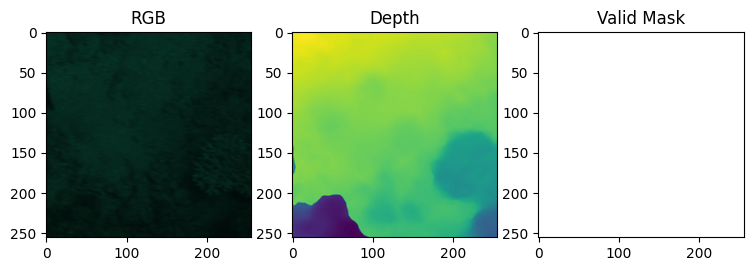

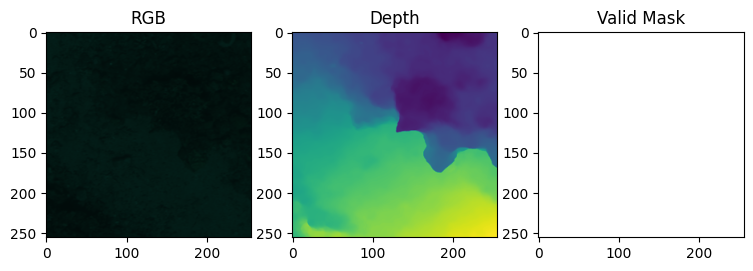

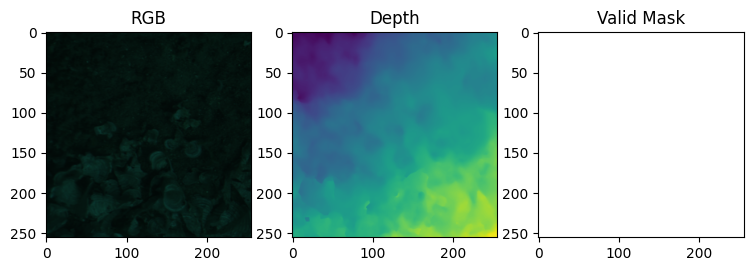

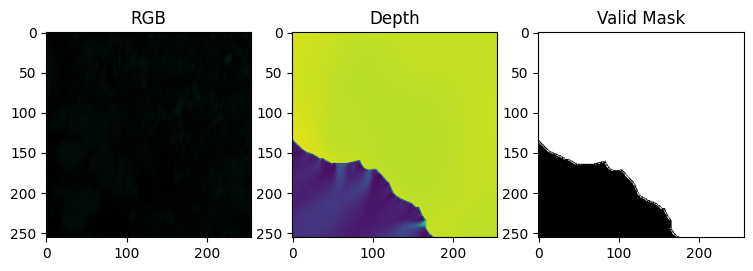

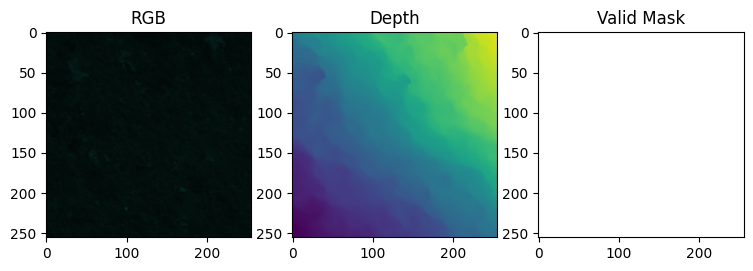

In [15]:
# VISUALIZATION
for rgb_batch, depth_batch, mask_batch in train_ds.take(1):
    for i in range(5):
        plt.figure(figsize=(9, 3))

        plt.subplot(1, 3, 1)
        plt.imshow((rgb_batch[i].numpy() + 1) / 2)
        plt.title("RGB")

        plt.subplot(1, 3, 2)
        plt.imshow(
            depth_batch[i].numpy(),
            cmap="viridis"
        )
        plt.title("Depth")

        plt.subplot(1, 3, 3)
        plt.imshow(
            mask_batch[i].numpy(),
            cmap="gray",
            vmin=0,
            vmax=1
        )
        plt.title("Valid Mask")

        plt.show()

In [17]:
# DEBUG CHECK
# Check valid mask
for i in range(10):
    sample = load_image_depth(
        train_pairs[i][0],
        train_pairs[i][1]
    )

    _, _, mask = sample

    print(
        f"Sample {i}:",
        "unique =", np.unique(mask),
        "mean =", mask.mean()
    )

Sample 0: unique = [1.] mean = 1.0
Sample 1: unique = [0. 1.] mean = 0.8762782
Sample 2: unique = [0. 1.] mean = 0.91807485
Sample 3: unique = [1.] mean = 1.0
Sample 4: unique = [0. 1.] mean = 0.76454335
Sample 5: unique = [0. 1.] mean = 0.99813676
Sample 6: unique = [1.] mean = 1.0
Sample 7: unique = [0. 1.] mean = 0.9992361
Sample 8: unique = [0. 1.] mean = 0.999983
Sample 9: unique = [0. 1.] mean = 0.93871874


In [18]:
# Check RGB bit depth
img = cv2.imread(train_pairs[0][0], cv2.IMREAD_UNCHANGED)
print("dtype:", img.dtype)
print("max:", img.max())
print("min:", img.min())

dtype: uint16
max: 32328
min: 233


In [19]:
# Check normalization ranges
for rgb_batch, depth_batch, mask_batch in train_ds.take(1):
    print("RGB min:", tf.reduce_min(rgb_batch).numpy())
    print("RGB max:", tf.reduce_max(rgb_batch).numpy())

    print("Depth min:", tf.reduce_min(depth_batch).numpy())
    print("Depth max:", tf.reduce_max(depth_batch).numpy())

RGB min: -0.9973144
RGB max: -0.23372245
Depth min: 4.064442e-08
Depth max: 0.3787372


In [20]:
# Check dataset batches
print("Train batches:", tf.data.experimental.cardinality(train_ds).numpy())
print("Val batches:", tf.data.experimental.cardinality(val_ds).numpy())
print("Test batches:", tf.data.experimental.cardinality(test_ds).numpy())

Train batches: -1
Val batches: -2
Test batches: -2


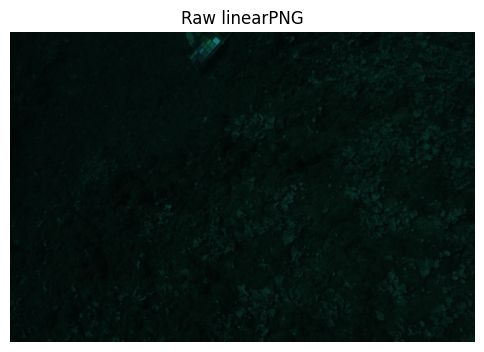

In [21]:
img = cv2.imread(train_pairs[0][0], cv2.IMREAD_UNCHANGED)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,6))
plt.imshow(img / 65535.0)
plt.title("Raw linearPNG")
plt.axis("off")
plt.show()